# CSE422 Lab Project: Obesity Dataset Analysis

This notebook is prepared for the CSE422 lab project using `Updated_Obesity_Dataset.csv`.
It follows the project structure requested in class: dataset description, EDA, preprocessing,
dataset splitting, supervised learning models, model comparison, and unsupervised clustering with KMeans.

In [ ]:
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

DATA_CANDIDATES = [
    Path(r"C:\Users\tamim\Downloads\Updated_Obesity_Dataset.csv"),
    Path("Updated_Obesity_Dataset.csv"),
    Path("/content/Updated_Obesity_Dataset.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Updated_Obesity_Dataset.csv was not found. Update DATA_CANDIDATES with the correct path.")

OUTPUT_DIR = Path("obesity_notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = "NObeyesdad"

print("Using dataset:", DATA_PATH)
print("Artifacts will be saved to:", OUTPUT_DIR.resolve())

Using dataset: Updated_Obesity_Dataset.csv
Artifacts will be saved to: /content/obesity_notebook_outputs


## 1. Introduction

The goal of this project is to analyze obesity-related lifestyle and physical-condition data and build machine learning models that can predict obesity categories. The problem is important because obesity is influenced by multiple behavioral and biological factors, and data-driven models can help reveal useful patterns among those factors.

In [ ]:
# Safe reload in case this cell is run before the main import/setup cell.
try:
    pd
except NameError:
    import numpy as np
    import pandas as pd
    from pathlib import Path
    from IPython.display import display

try:
    DATA_PATH
except NameError:
    DATA_CANDIDATES = [
        Path(r"C:\\Users\\tamim\\Downloads\\Updated_Obesity_Dataset.csv"),
        Path("Updated_Obesity_Dataset.csv"),
        Path("/content/Updated_Obesity_Dataset.csv"),
    ]
    DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
    if DATA_PATH is None:
        raise FileNotFoundError("Updated_Obesity_Dataset.csv was not found. Update DATA_CANDIDATES with the correct path.")

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Dataset Description

This section answers the basic questions about the dataset and then performs exploratory data analysis.

In [ ]:
print("Column names:")
print(df.columns.tolist())
print()

print("Data types:")
print(df.dtypes)
print()

print("Non-null counts and summary:")
df.info()

Column names:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']

Data types:
Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64
NCP                               float64
SCC                                object
SMOKE                              object
CH2O                              float64
family_history_with_overweight     object
FAF                               float64
TUE                               float64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

Non-null counts and summary:
<class 'pandas.core.frame.DataFrame'>
Rang

In [ ]:
# Treat empty strings as missing values so the missing-value analysis is accurate.
df = df.replace(r"^\s*$", np.nan, regex=True)

num_rows, num_cols = df.shape
feature_count = num_cols - 1

X_full = df.drop(columns=[TARGET_COLUMN])
y_full = df[TARGET_COLUMN]

numeric_cols = X_full.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_full.select_dtypes(exclude=np.number).columns.tolist()

print(f"Number of data points: {num_rows}")
print(f"Number of input features: {feature_count}")
print(f"Output/target feature: {TARGET_COLUMN}")
print()
print("Problem type: Classification")
print("Reason: the target column contains multiple named obesity categories instead of a continuous numeric value.")
print()
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)
print()
print("Categorical variables need encoding because most machine learning models require numeric input values.")

Number of data points: 2111
Number of input features: 16
Output/target feature: NObeyesdad

Problem type: Classification
Reason: the target column contains multiple named obesity categories instead of a continuous numeric value.

Numeric features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical features: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']

Categorical variables need encoding because most machine learning models require numeric input values.


In [ ]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print("Missing values per column:")
display(missing_summary.to_frame("missing_count"))

Missing values per column:


,missing_count
family_history_with_overweight,21
CH2O,21
Gender,11


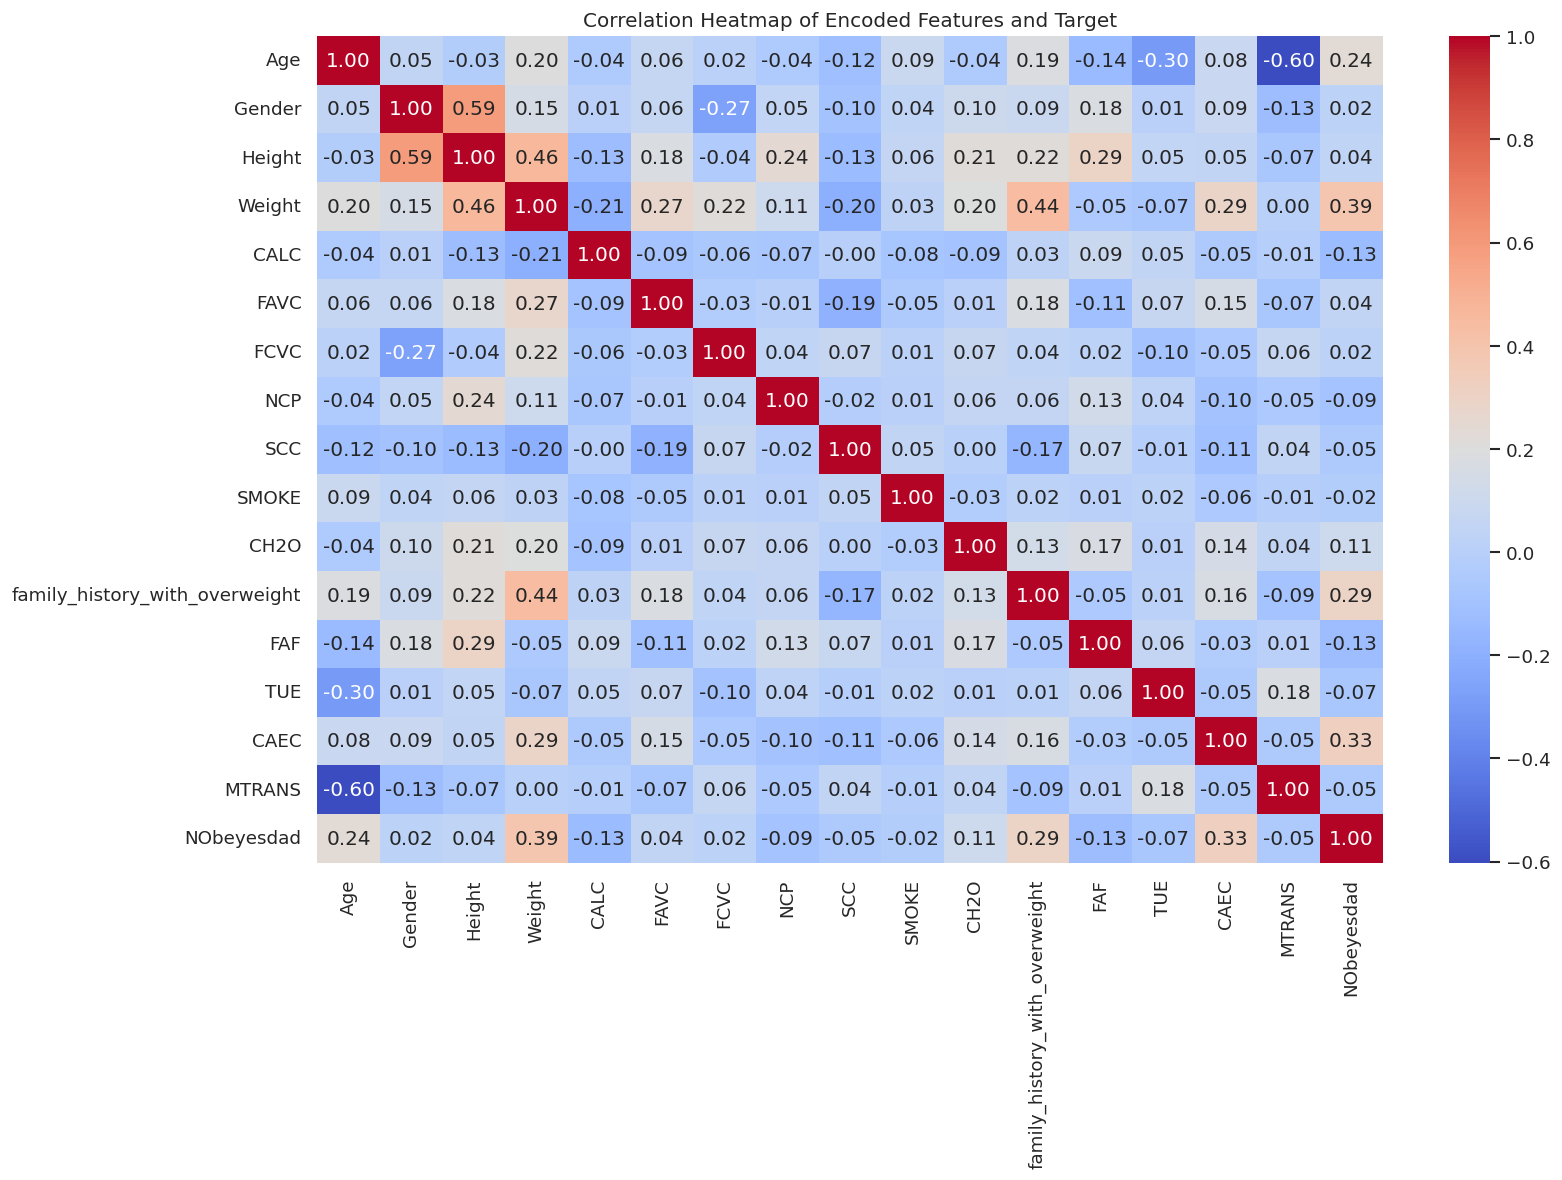

Top correlations with target:


,correlation_with_target
NObeyesdad,1.000000
Weight,0.387643
CAEC,0.327295
family_history_with_overweight,0.293649
Age,0.236170
CH2O,0.106673
FAVC,0.044582
Height,0.038986
Gender,0.020941
FCVC,0.018522


In [ ]:
# Correlation heatmap for all features + target.
# Categorical columns are label-encoded only for correlation analysis.
corr_df = df.copy()

for col in corr_df.columns:
    if corr_df[col].dtype == "object":
        corr_df[col] = corr_df[col].fillna("Missing")
        encoder = LabelEncoder()
        corr_df[col] = encoder.fit_transform(corr_df[col].astype(str))
    else:
        corr_df[col] = corr_df[col].fillna(corr_df[col].median())

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=False)
plt.title("Correlation Heatmap of Encoded Features and Target")
plt.tight_layout()
plt.show()

print("Top correlations with target:")
target_corr = corr_matrix[TARGET_COLUMN].sort_values(ascending=False)
display(target_corr.to_frame("correlation_with_target"))

Class distribution:


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


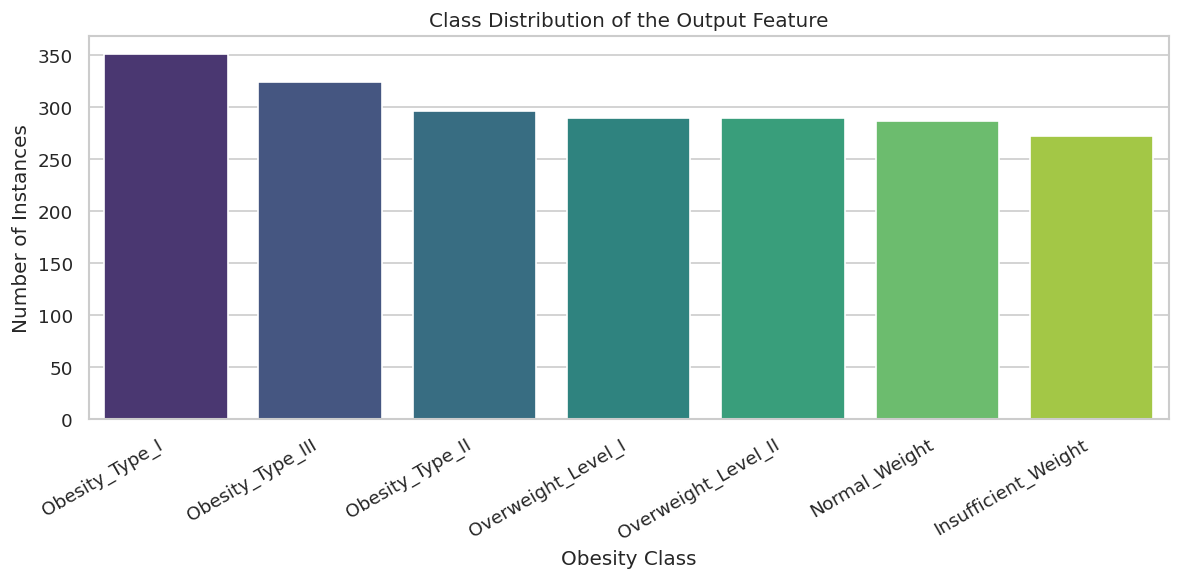

Observation: the dataset is not perfectly balanced, but the class sizes are not extremely skewed either.


In [ ]:
class_counts = y_full.value_counts().sort_values(ascending=False)
print("Class distribution:")
display(class_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution of the Output Feature")
plt.xlabel("Obesity Class")
plt.ylabel("Number of Instances")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Observation: the dataset is not perfectly balanced, but the class sizes are not extremely skewed either.")

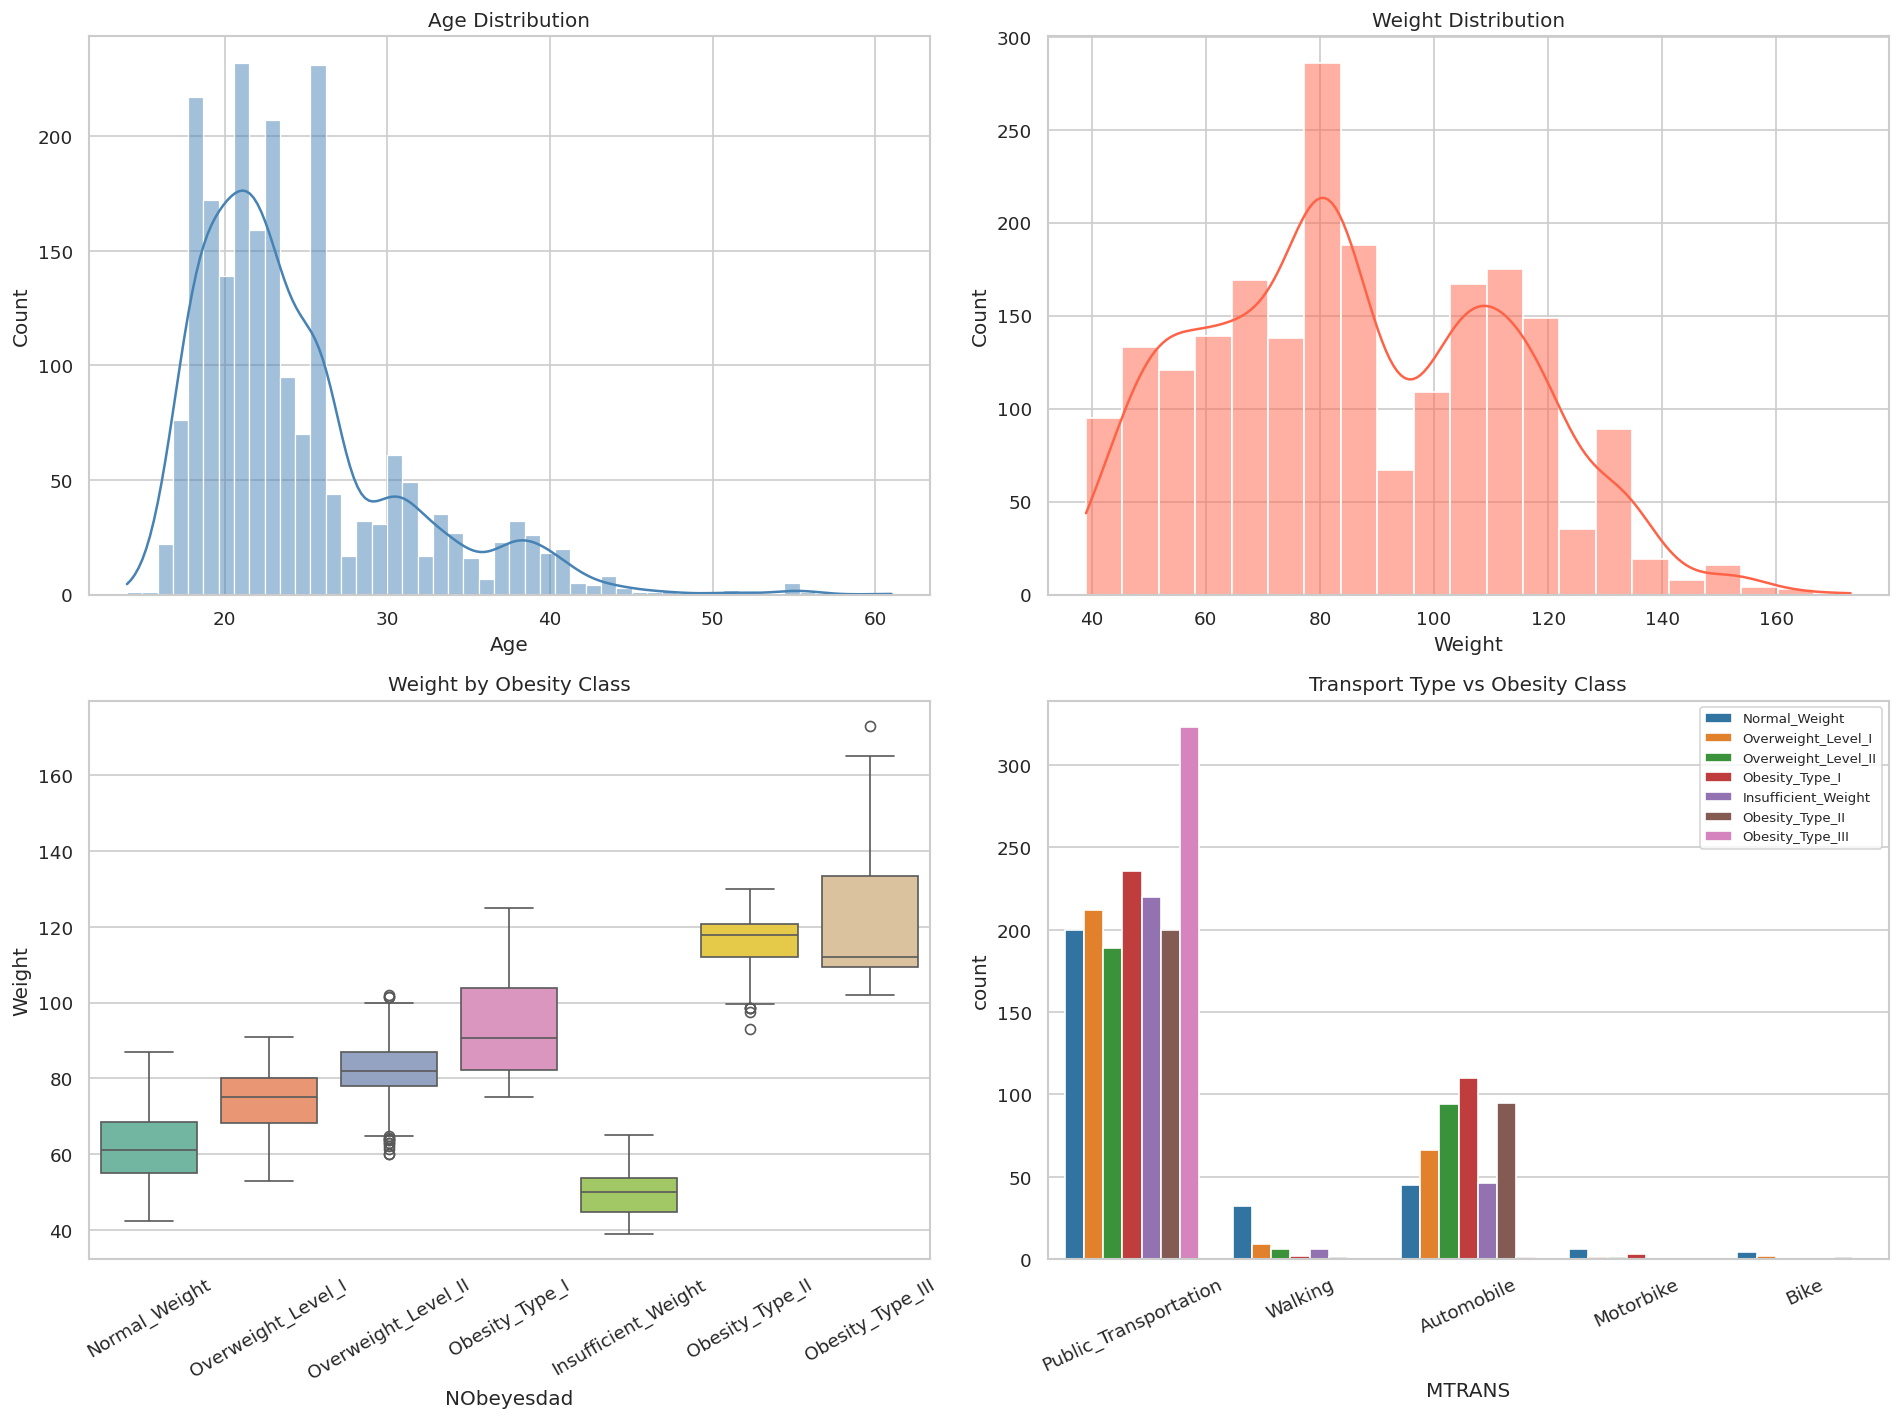

In [ ]:
# Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df["Age"], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age Distribution")

sns.histplot(df["Weight"], kde=True, ax=axes[0, 1], color="tomato")
axes[0, 1].set_title("Weight Distribution")

sns.boxplot(data=df, x=TARGET_COLUMN, y="Weight", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Weight by Obesity Class")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="MTRANS", hue=TARGET_COLUMN, ax=axes[1, 1], palette="tab10")
axes[1, 1].set_title("Transport Type vs Obesity Class")
axes[1, 1].tick_params(axis="x", rotation=25)
axes[1, 1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Dataset Pre-processing

In this dataset, the main issues are missing values, categorical variables, and feature scaling.
The preprocessing pipeline below solves each problem in order.

In [ ]:
print("Rows before preprocessing:", df.shape[0])
print("Columns before preprocessing:", df.shape[1])
print()
print("Problems found:")
print("1. Missing values exist in Gender, CH2O, and family_history_with_overweight.")
print("2. Several features are categorical and cannot be used directly by most ML models.")
print("3. Features such as Age, Height, Weight, CH2O, FAF, and TUE are on different scales.")

Rows before preprocessing: 2111
Columns before preprocessing: 17

Problems found:
1. Missing values exist in Gender, CH2O, and family_history_with_overweight.
2. Several features are categorical and cannot be used directly by most ML models.
3. Features such as Age, Height, Weight, CH2O, FAF, and TUE are on different scales.


In [ ]:
X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    sparse_threshold=0.0,
)

print("Solutions applied:")
print("1. Missing numeric values are imputed with the median to reduce the effect of outliers.")
print("2. Missing categorical values are imputed with the most frequent category.")
print("3. Categorical features are one-hot encoded.")
print("4. Numeric features are standardized using StandardScaler.")

Solutions applied:
1. Missing numeric values are imputed with the median to reduce the effect of outliers.
2. Missing categorical values are imputed with the most frequent category.
3. Categorical features are one-hot encoded.
4. Numeric features are standardized using StandardScaler.


## 4. Dataset Splitting

Because this is a classification problem with multiple classes and slightly unequal class frequencies, stratified splitting is more appropriate than a plain random split.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print()
print("Train class distribution:")
display(y_train.value_counts().sort_index().to_frame("train_count"))
print("Test class distribution:")
display(y_test.value_counts().sort_index().to_frame("test_count"))

Train set shape: (1688, 16)
Test set shape: (423, 16)

Train class distribution:


,train_count
NObeyesdad,
Insufficient_Weight,218
Normal_Weight,229
Obesity_Type_I,281
Obesity_Type_II,237
Obesity_Type_III,259
Overweight_Level_I,232
Overweight_Level_II,232


Test class distribution:


,test_count
NObeyesdad,
Insufficient_Weight,54
Normal_Weight,58
Obesity_Type_I,70
Obesity_Type_II,60
Obesity_Type_III,65
Overweight_Level_I,58
Overweight_Level_II,58


## 5. Model Training and Testing (Supervised)

This notebook trains five classification models:
- K-Nearest Neighbors (KNN)
- Decision Tree
- Logistic Regression
- Naive Bayes
- Neural Network (MLPClassifier)

It also treats the task as an unsupervised learning problem later using KMeans.

In [ ]:
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE),
}

results = []
trained_models = {}
roc_data = {}
conf_matrices = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    auc_score = np.nan
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)
        auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_data[model_name] = (fpr, tpr, auc(fpr, tpr))

    conf_matrices[model_name] = confusion_matrix(y_test, y_pred, labels=classes)
    trained_models[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC (OvR)": auc_score,
    })

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))


KNN Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.73      0.94      0.82        54
      Normal_Weight       0.79      0.40      0.53        58
     Obesity_Type_I       0.75      0.94      0.84        70
    Obesity_Type_II       0.91      0.97      0.94        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.73      0.69      0.71        58
Overweight_Level_II       0.76      0.67      0.72        58

           accuracy                           0.81       423
          macro avg       0.81      0.80      0.79       423
       weighted avg       0.81      0.81      0.80       423


Decision Tree Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.87      0.92        54
      Normal_Weight       0.79      0.86      0.83        58
     Obesity_Type_I       0.93      0.93      0.93        70
    Obesity_Type_

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "AUC (OvR)": "{:.4f}",
}))

results_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)

,Model,Accuracy,Precision,Recall,F1 Score,AUC (OvR)
0,Neural Network,0.9527,0.9518,0.9515,0.9515,0.9967
1,Decision Tree,0.9149,0.9162,0.9126,0.9137,0.9490
2,Logistic Regression,0.8771,0.8738,0.8745,0.8734,0.9834
3,KNN,0.8085,0.8078,0.8018,0.7912,0.9689
4,Naive Bayes,0.5059,0.5198,0.4982,0.4491,0.8365


## 6. Model Selection / Comparison Analysis

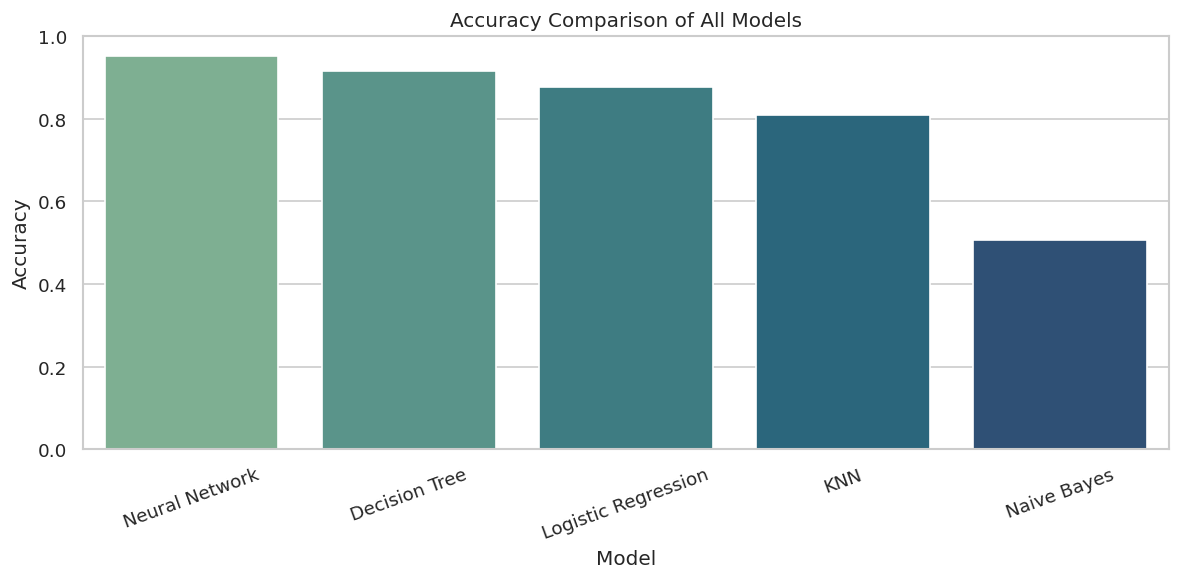

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="crest")
plt.title("Accuracy Comparison of All Models")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

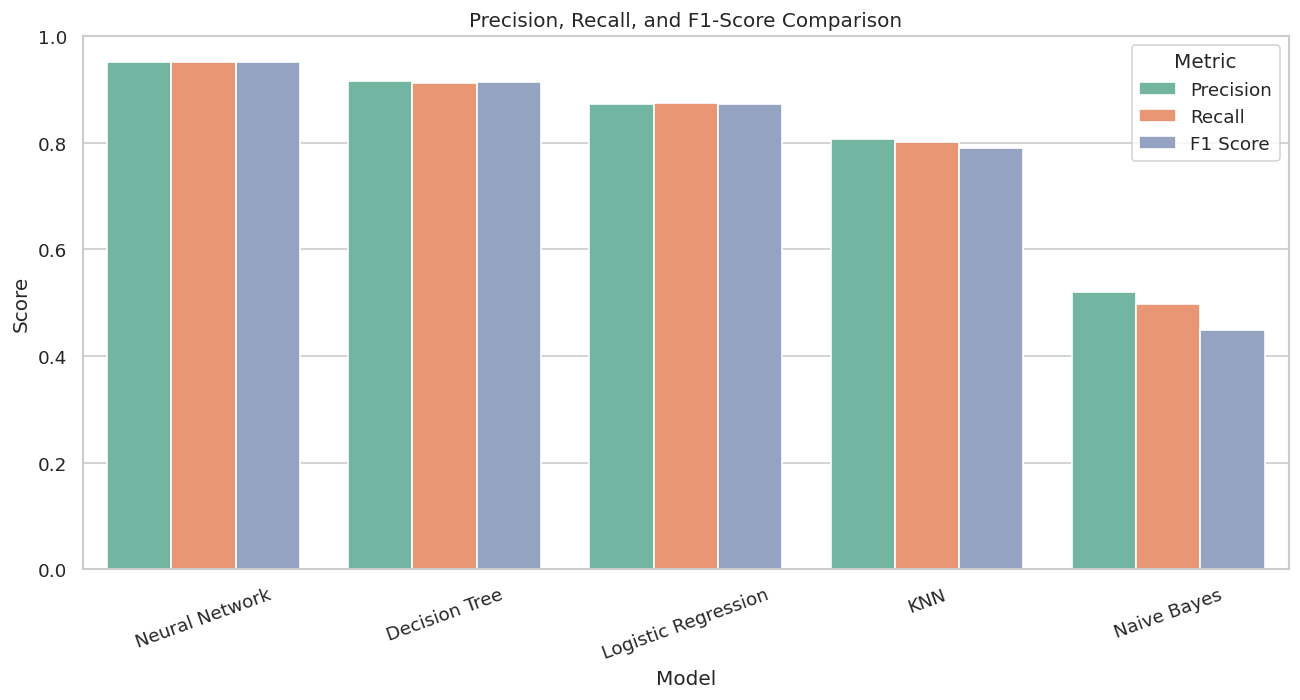

In [ ]:
metrics_long = results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=metrics_long, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Precision, Recall, and F1-Score Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

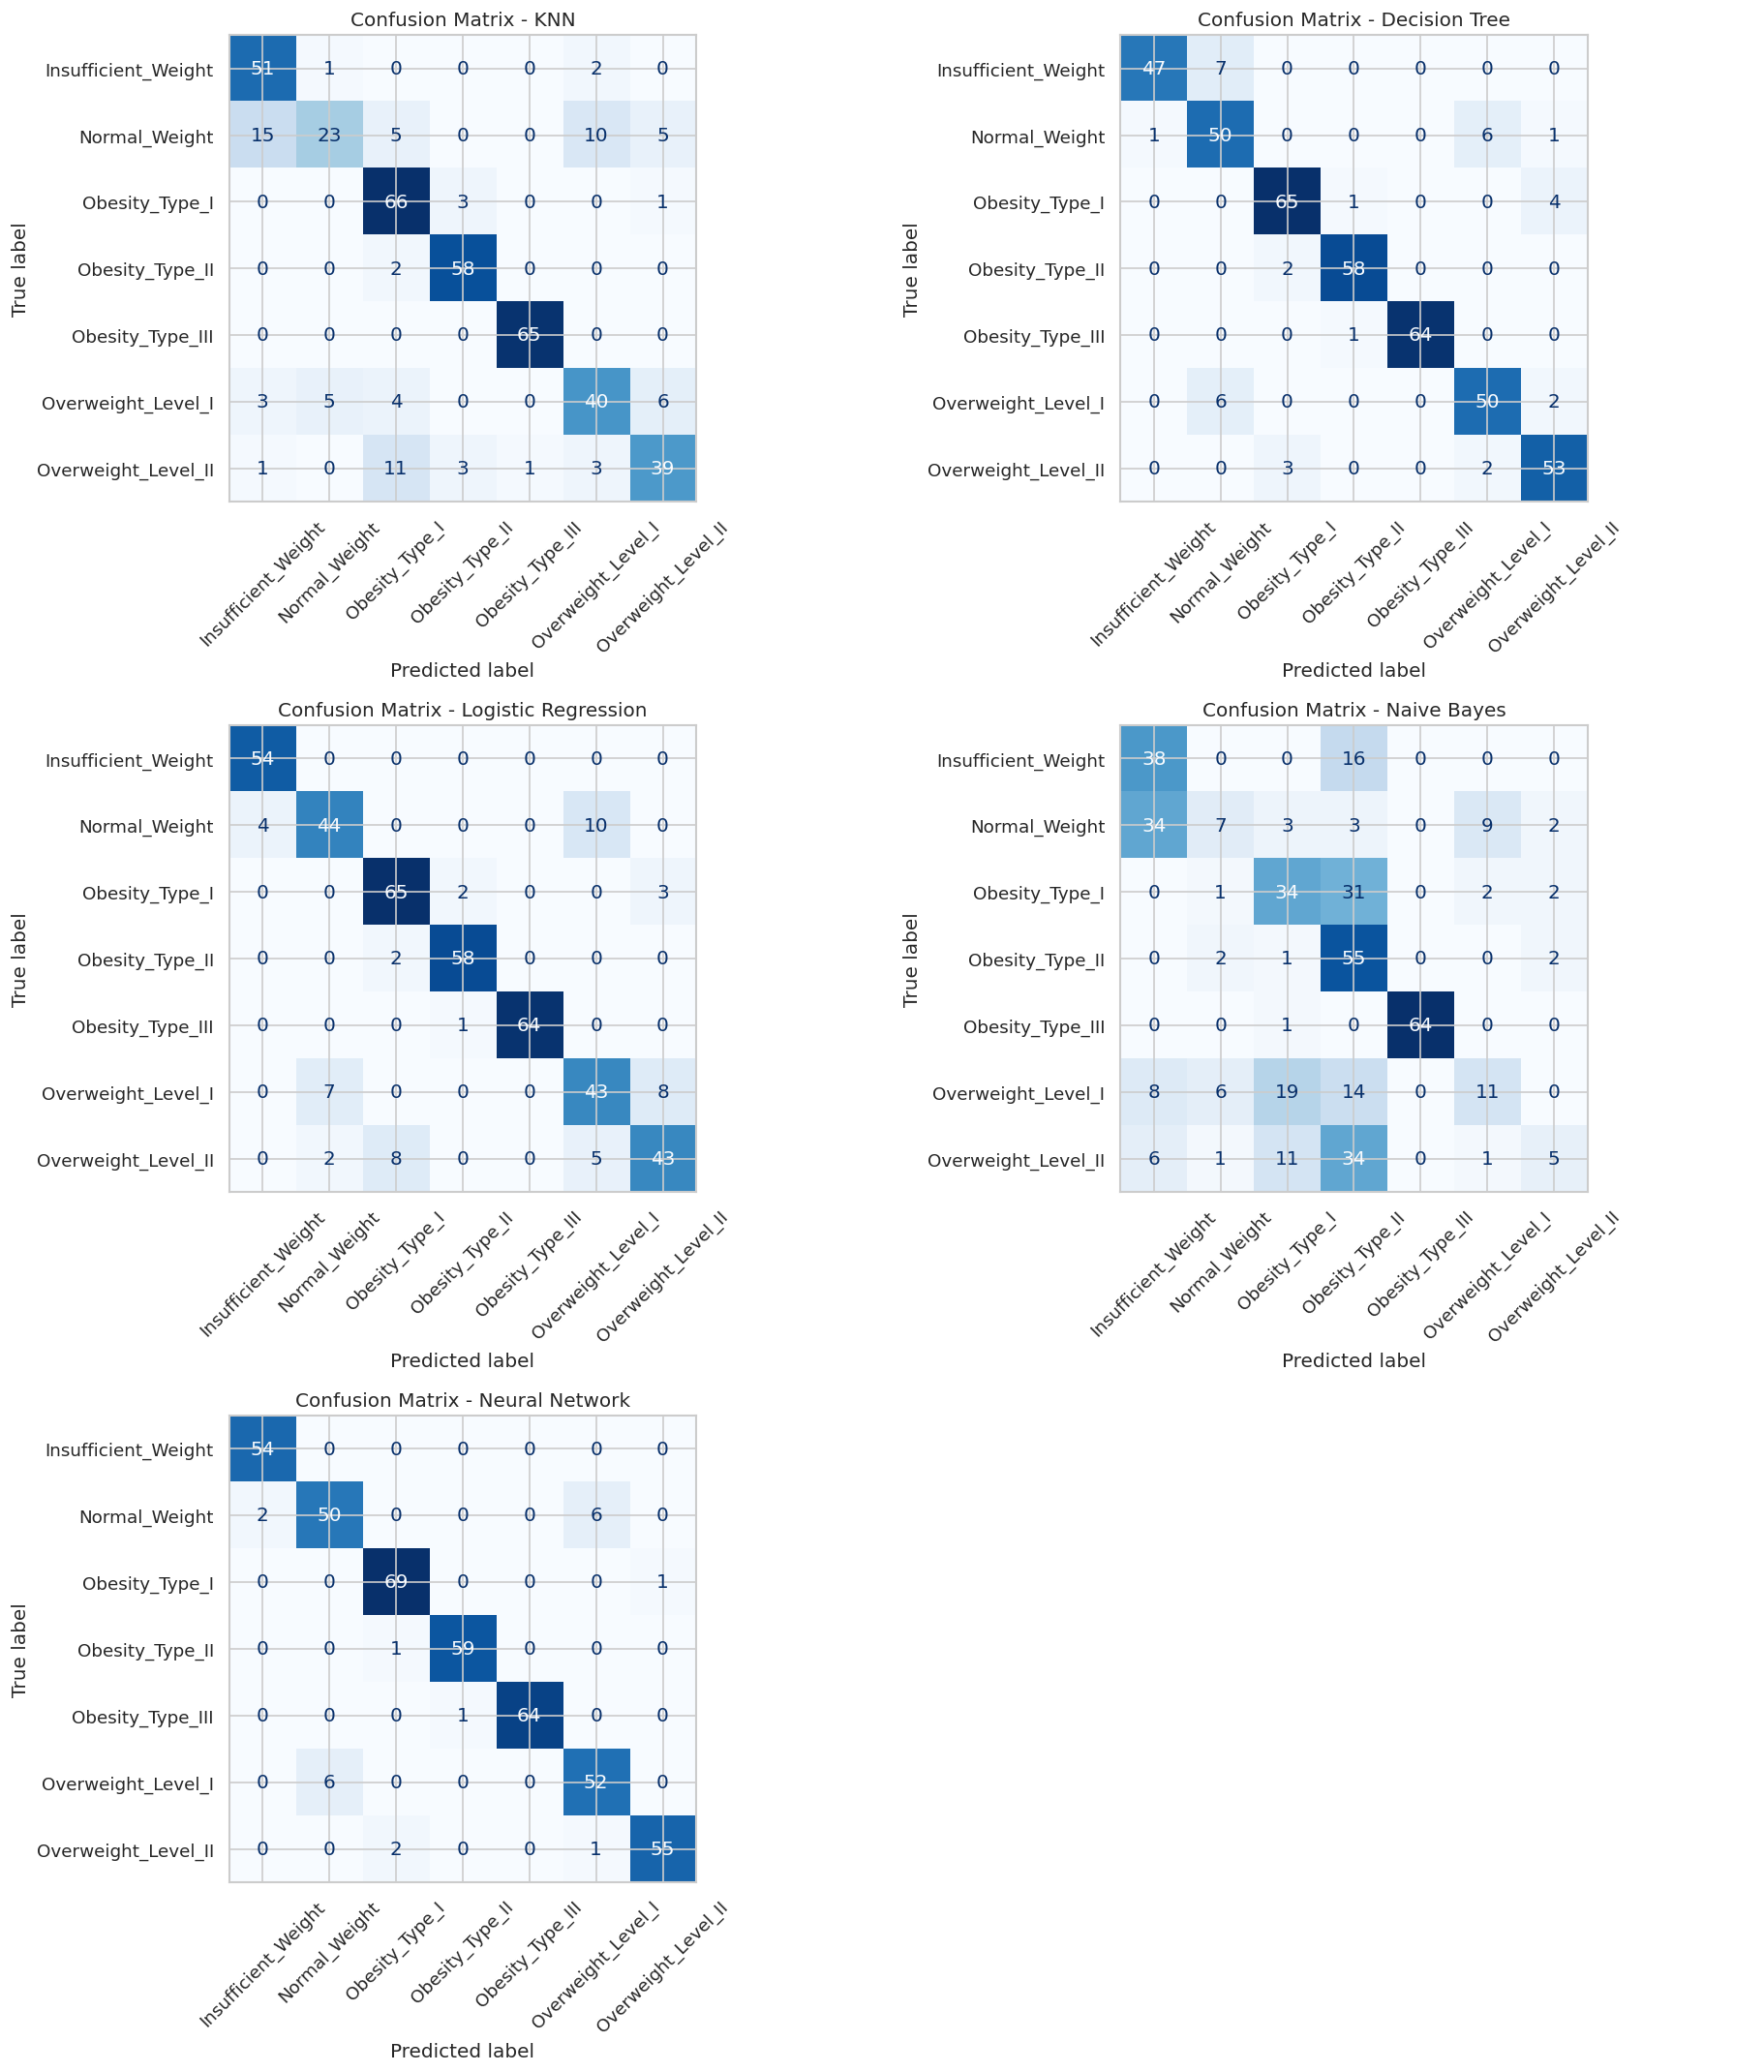

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, (model_name, cm) in enumerate(conf_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False, values_format="d")
    axes[idx].set_title(f"Confusion Matrix - {model_name}")
    axes[idx].tick_params(axis="x", rotation=45)

if len(conf_matrices) < len(axes):
    for idx in range(len(conf_matrices), len(axes)):
        axes[idx].axis("off")

plt.tight_layout()
plt.show()

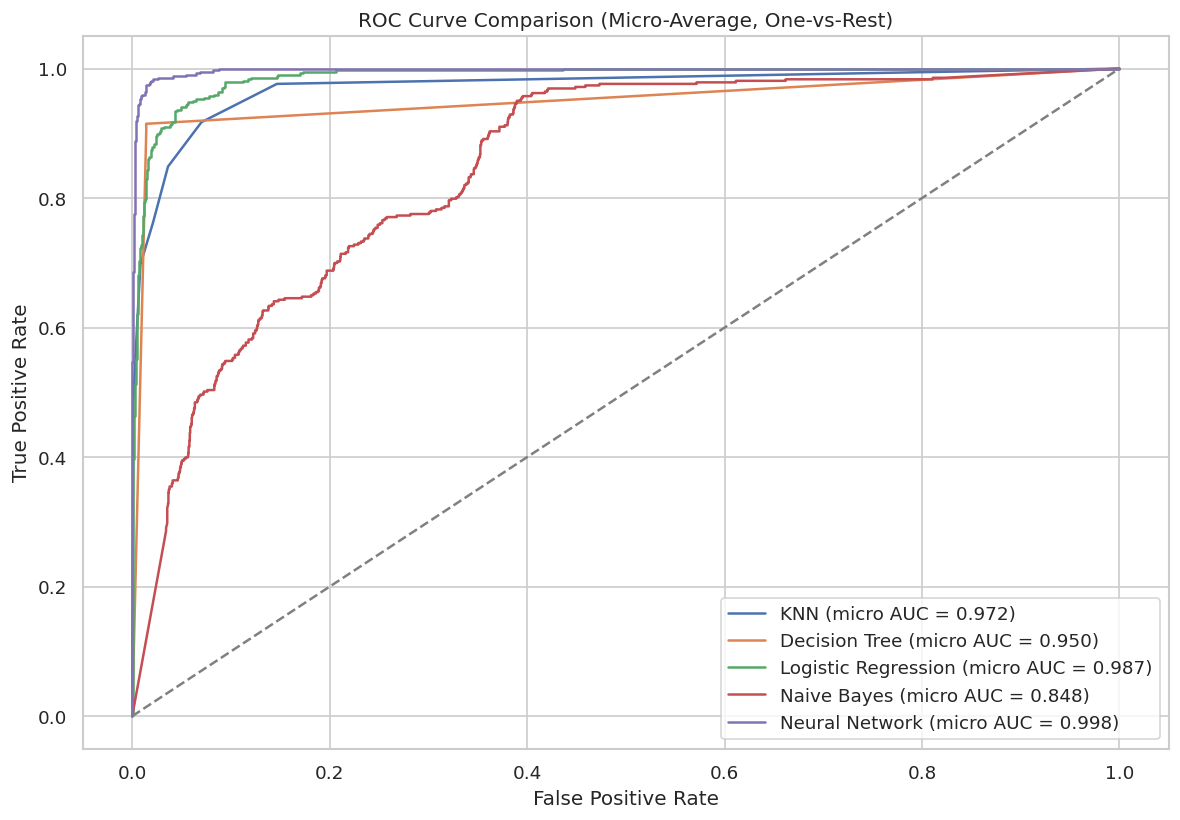

In [ ]:
plt.figure(figsize=(10, 7))
for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (micro AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Micro-Average, One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_model_row = results_df.iloc[0]
print("Best model based on accuracy:")
display(best_model_row.to_frame(name="value"))

Best model based on accuracy:


,value
Model,Neural Network
Accuracy,0.952719
Precision,0.951758
Recall,0.951509
F1 Score,0.951461
AUC (OvR),0.996692


## 5 (Unsupervised Part). KMeans Clustering

Now we ignore the labels and treat the dataset as an unsupervised learning problem.
The number of clusters is chosen as the number of real obesity classes.

In [ ]:
X_processed = preprocessor.fit_transform(X)

k = y.nunique()
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_processed)

cluster_counts = pd.Series(clusters).value_counts().sort_index()
cluster_counts.index.name = "Cluster"
cluster_counts.name = "Count"

print("KMeans cluster counts:")
display(cluster_counts.to_frame())

sil_score = silhouette_score(X_processed, clusters)
print(f"Silhouette Score: {sil_score:.4f}")

KMeans cluster counts:


,Count
Cluster,
0,268
1,281
2,263
3,334
4,285
5,279
6,401


Silhouette Score: 0.1508


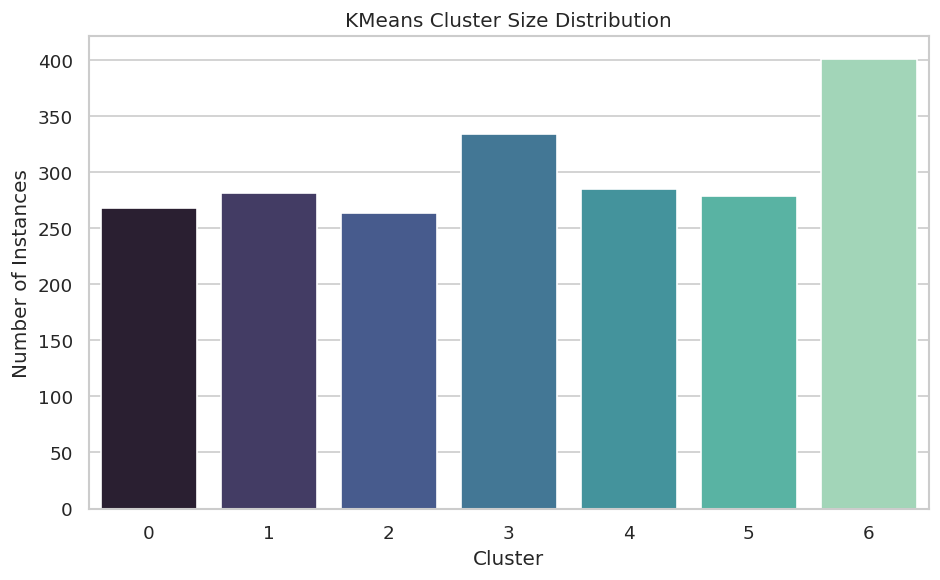

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="mako")
plt.title("KMeans Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Instances")
plt.tight_layout()
plt.show()

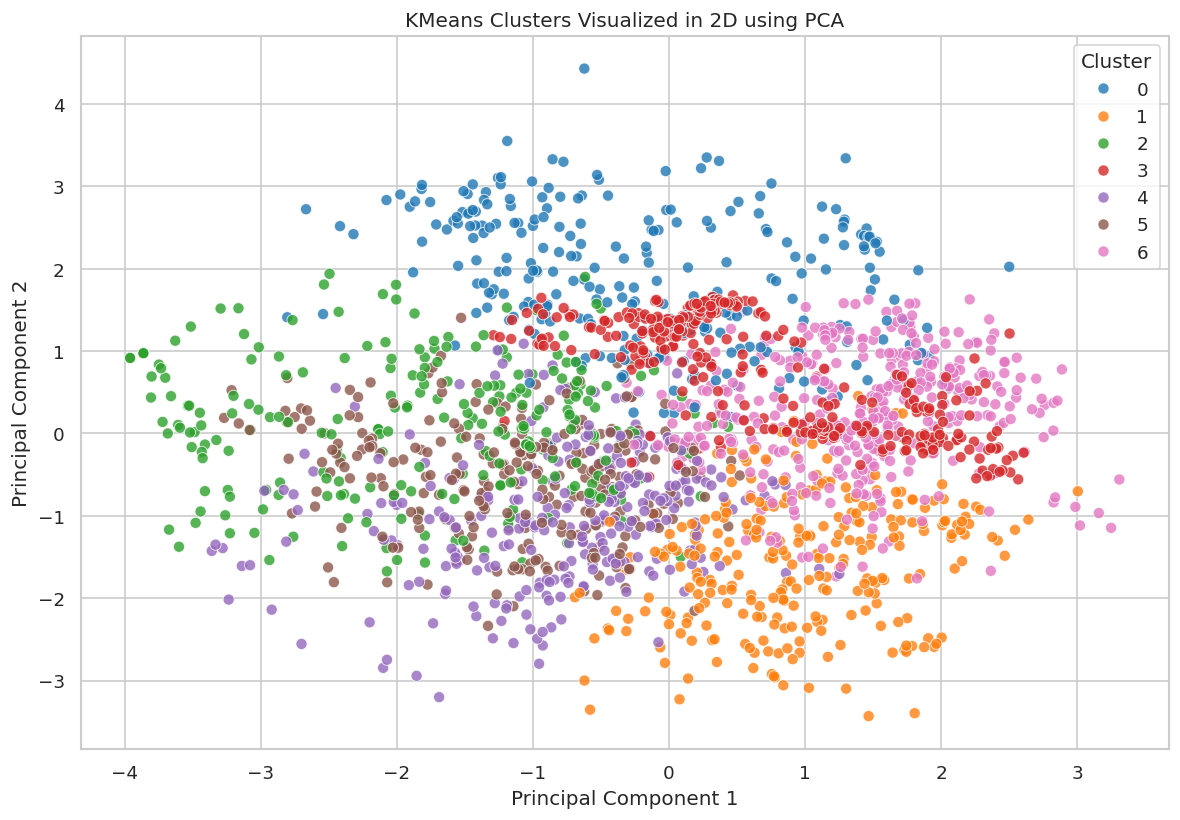

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="tab10", s=45, alpha=0.8)
plt.title("KMeans Clusters Visualized in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()